# Explainability for Digital Pathology — ECDP 2026 Summer School

This notebook runs best on a **GPU**. On Google Colab it's free but off by
default, so enable it before running anything:

> **Runtime → Change runtime type → Hardware accelerator → GPU → Save**

A GPU isn't strictly required — the code falls back to CPU automatically — but
the occlusion and Grad-CAM passes will be noticeably slower without one.

To check it worked, run the device-setup cell below: it should print
`Running on: cuda`. If it says `cpu`, revisit the steps above (and make sure you
clicked **Save**).

In this notebook, we will be using a pathology data viewing through [xOpat](https://xopat.org). Whether you have an experience with slide viewers or not, we would love to have Your feedback both on the viewer usability, and also on the summer school itself. You can find the link at the end of this notebook.


In [ ]:
# Install dependencies not available by default in Colab
!pip uninstall -qqq -y albumentations
!pip install -qqq "numpy==2.2.2" "captum==0.9.0" "openslide-bin==4.0.1.1" "ratiopath==1.4.1" "albumentationsx[headless]==2.3.1" "pyvips[binary]==3.1.1" "xopat==1.0.35" git+https://github.com/RationAI/zennit-crp.git@7ac08f2e9edc2fe6086c86bfd1ef7a1fc796e8d7

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: Cannot install Pillow==11.3.0, ratiopath==1.4.1 and zennit-crp==0.6.0+vit because these package versions have conflicting dependencies.
ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts


In [ ]:
import gdown

folder_id = "1fZHYl22MB4kvAeaPeZYDP3ZQ-jEXb2SV"
gdown.download_folder(id=folder_id, quiet=False, use_cookies=False)

Retrieving folder contents


Processing file 1f8titujgFIVbNJR4pe_JHPS8RGvp3WrG checkpoint.ckpt
Processing file 1qwALlAxpqni0J6ktG97SPm8MXJCD2AEg gradcam_mask_precomputed_old.tiff
Processing file 11I_0ATWsfguOnHwUcW_kGb3IuM7XE3W5 gradcam_mask_precomputed.tiff
Processing file 1EHhVi68hepthmOD24y46rhDchiFjKNSS heatmap_mask_precomputed.tiff
Processing file 1FIAoqVfEe1ctcM66keI69g5ou8UsFzxA occlusion_mask_precomputed.tiff
Processing file 1wDu6v06kLvFxaTdbLWJlzMdmDnKTdpZt slide_metadata_224.parquet
Processing file 1Eo2Wb7d_zUS-ObdRP_lOAv8JsY784Bnv slide_metadata.parquet
Processing file 1O1zrqAHUbGVxCpayOADB1Gxs0t-RBm7G slide.tiff
Processing file 1az8ZXa7k9GiFG_qWaim3URshJ2RGVqrq tiles_224.parquet
Processing file 1mJ5s9_wJQPar2KUcs4o_MtvOSU57j2O5 tiles.parquet
Processing file 1k7oLIb383v4-W3DElhY6qnDsTNa62CrQ vit_crp_positive_mask.tiff


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1f8titujgFIVbNJR4pe_JHPS8RGvp3WrG
From (redirected): https://drive.google.com/uc?id=1f8titujgFIVbNJR4pe_JHPS8RGvp3WrG&confirm=t&uuid=20474cbc-2b42-4664-bf09-63b9e0a2e780
To: /content/ECDP2026/checkpoint.ckpt
100%|██████████| 177M/177M [00:01<00:00, 98.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1qwALlAxpqni0J6ktG97SPm8MXJCD2AEg
To: /content/ECDP2026/gradcam_mask_precomputed_old.tiff
100%|██████████| 2.83M/2.83M [00:00<00:00, 75.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=11I_0ATWsfguOnHwUcW_kGb3IuM7XE3W5
To: /content/ECDP2026/gradcam_mask_precomputed.tiff
100%|██████████| 3.58M/3.58M [00:00<00:00, 39.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1EHhVi68hepthmOD24y46rhDchiFjKNSS
To: /content/ECDP2026/heatmap_mask_precomputed.tiff
100%|██████████| 1.10M/1.10M [00:00<00:00, 54.1MB

['/content/ECDP2026/checkpoint.ckpt',
 '/content/ECDP2026/gradcam_mask_precomputed_old.tiff',
 '/content/ECDP2026/gradcam_mask_precomputed.tiff',
 '/content/ECDP2026/heatmap_mask_precomputed.tiff',
 '/content/ECDP2026/occlusion_mask_precomputed.tiff',
 '/content/ECDP2026/slide_metadata_224.parquet',
 '/content/ECDP2026/slide_metadata.parquet',
 '/content/ECDP2026/slide.tiff',
 '/content/ECDP2026/tiles_224.parquet',
 '/content/ECDP2026/tiles.parquet',
 '/content/ECDP2026/vit_crp_positive_mask.tiff']

---
## Model: VGG16-based Prostate Cancer Classifier

The model is a binary classifier built on top of **VGG16**, a classic CNN architecture originally introduced for ImageNet.

### Architecture
vgg16_prostate_classifier (1).svg

The model outputs a **raw logit**:
- **Positive** → model predicts cancer
- **Negative** → model predicts no cancer

To convert to a probability: `p = sigmoid(logit)`.

---

### BinaryClassifier

The classification head reduces the backbone's feature map to a single output logit:

1. **Global max pooling** — collapses dimensions `(B, 512, H', W')` → `(B, 512)`, making the head independent of input size
2. **Linear(512 → 1)** — projects to a single value; positive = cancer, negative = no cancer

In [ ]:
import torch.nn as nn
from torch import Tensor

class BinaryClassifier(nn.Module):
    """Single-neuron classifier on top of a CNN feature extractor.

    Global max pooling collapses the spatial dimensions so the head
    works regardless of the input tile size.
    """

    def __init__(self, in_features: int) -> None:
        super().__init__()
        self.global_pool = nn.AdaptiveMaxPool2d(1)
        self.proj = nn.Linear(in_features, 1)

    def forward(self, x: Tensor) -> Tensor:
        x = self.global_pool(x).flatten(start_dim=1)  # (B, C)
        return self.proj(x)  # raw logit — positive = cancer, negative = no cancer

### ProstateCancerModel

A thin wrapper that chains the backbone and head into a single `nn.Module`. Keeping them separate makes it easy to swap out either part — for example, replacing VGG16 with a different backbone.

In [ ]:
import torch.nn as nn
from torch import Tensor

class ProstateCancerModel(nn.Module):
    """VGG16 feature extractor + binary classification head."""

    def __init__(self, backbone: nn.Module, decode_head: nn.Module) -> None:
        super().__init__()
        self.backbone = backbone
        self.decode_head = decode_head

    def forward(self, x: Tensor) -> Tensor:
        return self.decode_head(self.backbone(x))

### Device setup

We select the compute device. If a GPU is available — enabled in Colab via *Runtime → Change runtime type* — all tensor operations run on it, which is significantly faster than CPU for neural networks. If no GPU is available the code falls back to CPU automatically.

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

Running on: cuda


### Instantiate the model

We create the VGG16 backbone and the classification head, then combine them. At this point the weights are randomly initialized — we fix that in the next step.

In [ ]:
from torchvision.models import vgg16

backbone = vgg16().features          # 5 conv blocks → (B, 512, H', W')
decode_head = BinaryClassifier(in_features=512)

model = ProstateCancerModel(backbone, decode_head)

### Load pre-trained weights

We load a checkpoint trained on a prostate cancer dataset and move the model to the selected device.

In [ ]:
import torch

checkpoint = torch.load("ECDP2026/checkpoint.ckpt", map_location="cpu")
model.load_state_dict(checkpoint["state_dict"])
model = model.eval().to(device)

print("Model loaded successfully.")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model loaded successfully.
Parameters: 14,715,201


---
## Dataset: Whole Slide Image Tiles

Pathology scans are **gigapixel images** — a single slide can be 100,000 × 50,000 pixels or more. Neural networks cannot process an image that large directly, so the standard approach is to divide the slide into a regular grid of smaller **tiles** and classify each one independently.

### Data files

| File | Description |
|------|-------------|
| `slide.tiff` | The whole slide image (WSI) |
| `slide_metadata.parquet` | Slide properties: pixel dimensions, resolution (µm/px), tile size, stride |
| `tiles.parquet` | Table of `(x, y)` coordinates — one row per tissue tile |

Only tiles that overlap with tissue are kept — empty background tiles are discarded during preprocessing.

### Two dataset instances

We create **two** `TileDataset` objects from the same slide:
- `tile_dataset` — applies normalization, used as model input
- `tile_dataset_unnormalized` — raw pixel values, used for visualization

---

### TileDataset

`TileDataset` is a standard PyTorch `Dataset` that wraps a whole slide image. It holds only the tile coordinates in memory — the actual pixel data is read from disk on demand when `__getitem__` is called.

Each item returned is a tuple of `(image_tensor, metadata)` where `metadata` carries the `(x, y)` coordinates of the tile on the slide. We'll need those coordinates later to place the attribution scores back onto the full slide.

The data reading heavily relies on OpenSlide, which is the backbone of opensource community in reading various slide formats across many vendors.

In [ ]:
from pathlib import Path
from typing import TypedDict

from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset
from ratiopath.openslide import OpenSlide

class Metadata(TypedDict):
    x: int
    y: int


class TileDataset(Dataset):
    """Lazily reads tiles from a single Whole Slide Image.

    Tiles are loaded on-the-fly from the slide file — only one tile
    is in memory at a time, keeping RAM usage low regardless of slide size.
    """

    def __init__(self, slide_path, level, tile_extent_x, tile_extent_y, tiles, transforms=None):
        self.slide_path = Path(slide_path)
        self.tiles = tiles
        self.level = level
        self.tile_extent_x = tile_extent_x
        self.tile_extent_y = tile_extent_y
        self.transforms = transforms
        self.to_tensor = ToTensorV2()

    def __len__(self):
        return len(self.tiles)

    def __getitem__(self, idx):
        row = self.tiles.iloc[idx]
        x, y = int(row["x"]), int(row["y"])

        with OpenSlide(self.slide_path) as slide:
            image = slide.read_tile(x, y, self.tile_extent_x, self.tile_extent_y, self.level)

        if self.transforms is not None:
            image = self.transforms(image=image)["image"]

        return self.to_tensor(image=image)["image"], Metadata(x=x, y=y)

### Load the slide data

We read two files: the slide metadata (physical dimensions, resolution, tile size) and the pre-computed tile coordinates. Only tiles that overlap with tissue are included — background tiles were filtered out during preprocessing.

In [ ]:
import pandas as pd

slide_metadata = pd.read_parquet("ECDP2026/slide_metadata.parquet").loc[0]
slide_metadata["path"] = "ECDP2026/slide.tiff"
tiles = pd.read_parquet("ECDP2026/tiles.parquet")

print(f"Slide dimensions : {slide_metadata['extent_x']} × {slide_metadata['extent_y']} px")
print(f"Tile size        : {slide_metadata['tile_extent_x']} × {slide_metadata['tile_extent_y']} px")
print(f"Resolution       : {slide_metadata['mpp_x']:.3f} µm/px")
print(f"Total tiles      : {len(tiles)}")

Slide dimensions : 28160 × 9216 px
Tile size        : 512 × 512 px
Resolution       : 0.468 µm/px
Total tiles      : 495


### Normalized dataset

We define a normalization transform using the mean and standard deviation computed from the training set, then wrap the slide in a `TileDataset` that applies it. This is the dataset we feed to the model.

In [ ]:
from albumentations import Normalize

normalize = Normalize(
    std=[27.8285, 51.4639, 26.4458],
    mean=[228.5544, 178.8584, 219.8793],
    max_pixel_value=1,
)

tile_dataset = TileDataset(
    slide_metadata["path"],
    slide_metadata["level"],
    slide_metadata["tile_extent_x"],
    slide_metadata["tile_extent_y"],
    tiles,
    transforms=normalize,
)

print(f"Normalized dataset: {len(tile_dataset)} tiles")

Normalized dataset: 495 tiles


### Unnormalized dataset

We keep a second dataset without normalization. Normalized pixel values are not visually meaningful — this copy lets us display tiles as they actually look under a microscope.

In [ ]:
tile_dataset_unnormalized = TileDataset(
    slide_metadata["path"],
    slide_metadata["level"],
    slide_metadata["tile_extent_x"],
    slide_metadata["tile_extent_y"],
    tiles,
)

print(f"Unnormalized dataset: {len(tile_dataset_unnormalized)} tiles")

Unnormalized dataset: 495 tiles


---
## Task: Occlusion Sensitivity Analysis with a CNN

In this task we explore **occlusion sensitivity analysis** — one of the simplest and most interpretable methods for understanding what parts of an image drive a CNN's prediction.

### How it works

The idea is straightforward:

> *If hiding a region of the image causes the model's confidence to drop, that region was important for the prediction.*

Concretely:
1. Take an input image and a trained model
2. Slide a small patch (the "occlusion window") across the image
3. At each position, replace the patch with a neutral baseline value (e.g., the background color)
4. Record how the model's output changes at each position
5. Build a heatmap — regions where occlusion causes the largest output change are the most important

This gives us an **attribution map**: a spatial heatmap of feature importance over the image.

---

### Step 1: Load a tile

We select a single tile from both dataset instances — normalized for the model and raw for display.


In [ ]:
tile, metadata = tile_dataset[0]
display_tile, _ = tile_dataset_unnormalized[0]

print(f"Tile shape (C, H, W): {tile.shape}")
print(f"Tile coordinates: x={metadata['x']}, y={metadata['y']}")

Tile shape (C, H, W): torch.Size([3, 512, 512])
Tile coordinates: x=2048, y=768


### Visualize the tile

Let's display the raw tile to see what tissue we're working with.

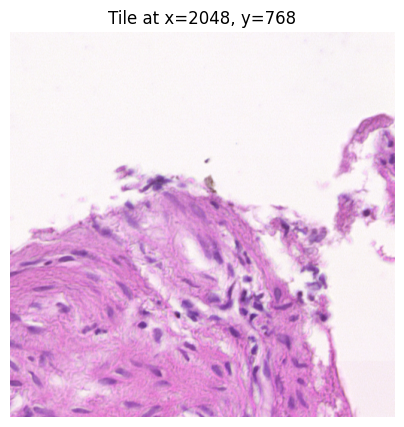

In [ ]:
import matplotlib.pyplot as plt

display_np = display_tile.permute(1, 2, 0).numpy()

plt.figure(figsize=(5, 5))
plt.imshow(display_np)
plt.title(f"Tile at x={metadata['x']}, y={metadata['y']}")
plt.axis("off")
plt.show()

### Step 2: Define the occlusion baseline

When we occlude a patch, we replace it with a **neutral value** — something that represents "no tissue information".

In histology, the slide background (no tissue) is white (RGB = 255, 255, 255). This is our natural choice: occluded regions are filled with white.

Since the model expects **normalized** inputs, we need to find what pure white maps to after our normalization transform.

In [ ]:
import numpy as np
import torch

# Compute the normalized value of a fully white (background) pixel
white_pixel = np.array([[[255, 255, 255]]], dtype=np.uint8)
normalized_white = normalize(image=white_pixel)["image"]

print("Normalized white pixel (R, G, B):", normalized_white[0, 0])

# This will be our baseline tensor for occlusion — shape (1, 3, 1, 1) for broadcasting
baseline = torch.tensor(normalized_white[0, 0]).view(1, 3, 1, 1)
print("Baseline tensor shape:", baseline.shape)

Normalized white pixel (R, G, B): [0.95030636 1.4795147  1.3280255 ]
Baseline tensor shape: torch.Size([1, 3, 1, 1])


### Step 3: Set up occlusion

We use [Captum](https://captum.ai/)'s `Occlusion` class, which handles the sliding window loop. We also move the tile and baseline to the selected device.

**Key parameters for `.attribute()`:**
- `sliding_window_shapes` — size of the occluded patch `(channels, height, width)`. Larger = coarser but faster.
- `strides` — step size in pixels. Smaller = finer resolution but slower.
- `baselines` — fill value for occluded regions (our normalized white pixel).
- `target` — which output to explain (`0` = our single binary logit).

In [ ]:
from captum.attr import Occlusion

input_tile = tile.unsqueeze(0).to(device)  # shape: (1, C, H, W)
baseline = baseline.to(device)

occlusion = Occlusion(model)

### Run attribution

> **Note:** This may take a minute — Captum runs one forward pass per occlusion position.

In [ ]:
attributions = occlusion.attribute(
    input_tile,
    sliding_window_shapes=(3, 55, 55),
    strides=25,
    baselines=baseline,
    target=0,
)

print("Attribution map shape:", attributions.shape)  # (1, C, H, W)

Attribution map shape: torch.Size([1, 3, 512, 512])


### Step 4: Process the attribution map

Following the [paper](https://www.sciencedirect.com/science/article/pii/S1871678423000511), we apply:

$$OP_{ij} = \sigma\bigl(f(P) - f(P_{ij})\bigr)$$

Captum's attribution already gives us `f(P) − f(P_ij)` per pixel. We sum across color channels (the window occludes all 3 simultaneously), apply sigmoid to normalize scale, then map `[0, 1] → [−1, 1]` via `2×OP − 1` so that:
- **+1** — occluding this region strongly reduces cancer confidence → region is important for cancer
- **0** — no effect
- **−1** — occluding this region increases cancer confidence → region suppresses cancer prediction

In [ ]:
attr = attributions.mean(dim=1, keepdim=True)  # (1, 1, H, W) — sum across channels

# Apply σ(f(P) − f(P_ij)) then scale [0, 1] → [−1, 1]
attr_scaled = (2 * torch.sigmoid(attr) - 1).squeeze().cpu().numpy()  # (H, W)

print(f"Attribution map shape: {attr_scaled.shape}")
print(f"Value range: [{attr_scaled.min():.3f}, {attr_scaled.max():.3f}]")

Attribution map shape: (512, 512)
Value range: [-0.142, 0.667]


### Visualize the results

We inspect the result on a single tile to ensure we did not make any errors. We plot the original tile, the attribution heatmap, and an overlay side by side.

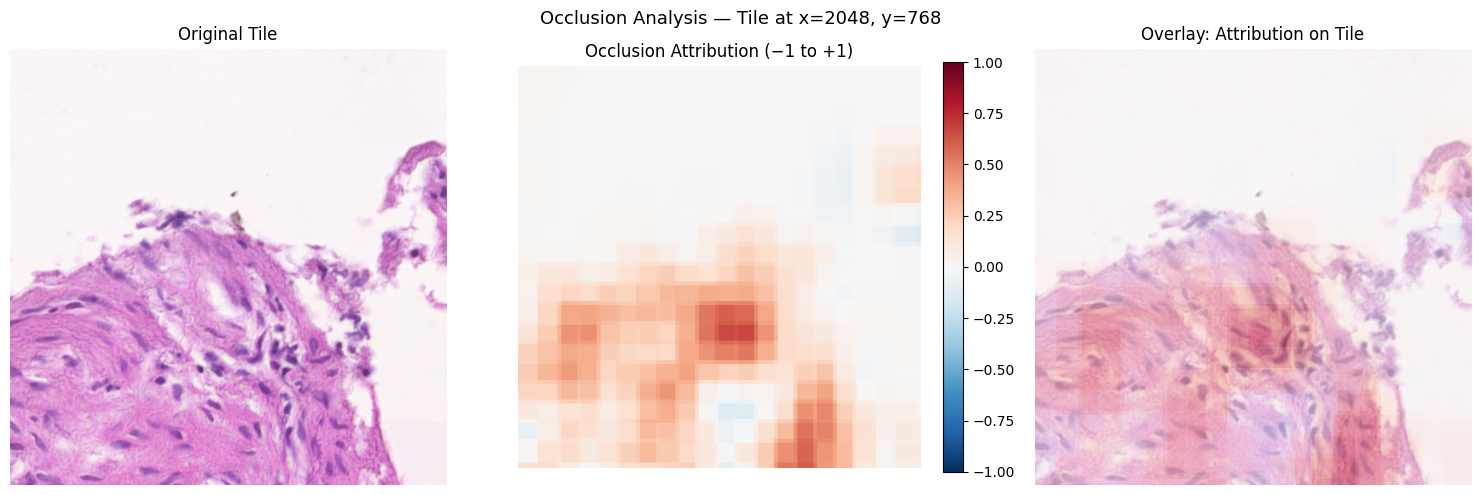

In [ ]:
import matplotlib.pyplot as plt

display_np = display_tile.permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(display_np)
axes[0].set_title("Original Tile")
axes[0].axis("off")

axes[1].imshow(attr_scaled, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_title("Occlusion Attribution (−1 to +1)")
axes[1].axis("off")
plt.colorbar(axes[1].images[0], ax=axes[1], fraction=0.046)

axes[2].imshow(display_np)
axes[2].imshow(attr_scaled, cmap="RdBu_r", vmin=-1, vmax=1, alpha=0.5)
axes[2].set_title("Overlay: Attribution on Tile")
axes[2].axis("off")

plt.suptitle(f"Occlusion Analysis — Tile at x={metadata['x']}, y={metadata['y']}", fontsize=13)
plt.tight_layout()
plt.show()

<table cellpadding="16" cellspacing="0" border="0"><tr><td bgcolor="#E1F5EE">
<font size="6" color="#085041"><b>Try this — change the occlusion settings</b></font>
<br><br>
<font size="4" color="#0a3d31">
The heatmap above is controlled by a few choices you can edit and re-run.
<br><br>
<b>1. Occlusion window and stride</b> (in the <i>Run attribution</i> cell):
<br>&nbsp;&nbsp;•&nbsp; <font size="4" face="Courier New, monospace" color="#7a2e0e"><b>sliding_window_shapes=(3, 55, 55)</b></font> — the size of the grey patch swept across the tile. Bigger patches give a coarser map but run faster;</br> smaller patches give finer detail but are slower.
<br>&nbsp;&nbsp;•&nbsp; <font size="4" face="Courier New, monospace" color="#7a2e0e"><b>strides=25</b></font> — how far the patch moves each step. A smaller stride (more overlap) gives a smoother, higher-resolution map at the cost of many</br>more forward passes.
<br><br>
Try <font size="4" face="Courier New, monospace" color="#7a2e0e"><b>sliding_window_shapes=(3, 25, 25)</b></font> with <font size="4" face="Courier New, monospace" color="#7a2e0e"><b>strides=10</b></font> for a finer map, or <font size="4" face="Courier New, monospace" color="#7a2e0e"><b>(3, 111, 111)</b></font> with <font size="4" face="Courier New, monospace" color="#7a2e0e"><b>strides=55</b></font> for a quick, coarse one.
<br><br>
<b>2. The tile</b> (in the <i>Load a tile</i> cell): swap <font size="4" face="Courier New, monospace" color="#7a2e0e"><b>tile_dataset[0]</b></font> for another index, e.g. <font size="4" face="Courier New, monospace" color="#7a2e0e"><b>tile_dataset[278]</b></font>, to inspect a different piece of tissue.
<br><br>
After editing, re-run the cells from your change down to <i>Visualize the results</i>. On the whole-slide pass further down you can also widen the sample</br>by editing <font size="4" face="Courier New, monospace" color="#7a2e0e"><b>TILE_INDICES</b></font>.
</font>
</td></tr></table>

---
### From a Single Tile to the Whole Slide

We now repeat the occlusion analysis for every tissue tile and stitch the
results back onto the slide. From the **same** occlusion passes we build two
complementary overlays:

- **Occlusion importance** — `σ(f(P) − f(P_ij))`, exactly the map from the
  single-tile analysis. Bipolar: regions that *drive* the cancer prediction
  vs. regions that *suppress* it.
- **Occluded-prediction heatmap** — `σ(f(P_ij))`, the model's score when each
  region is hidden. Because it is sampled at *every* window position it forms a
  smooth field across the slide, instead of one flat value per tile — brighter
  where hiding the tissue most collapses the cancer score, i.e. where the
  cancer signal lives.

`MaskBuilder` reassembles the tiles and `MeanAggregator` averages the
50 %-overlapping regions, smoothing the tile seams.

> **A caveat worth stating:** occlusion scores are computed *per tile*, each
> against that tile's own prediction `f(P)`, and are not calibrated to a common
> scale across the slide. Read these overlays *qualitatively* — "where did the
> model look", not a precisely comparable measurement.
---

### Initialize the mask builders

We create two identically configured builders — one per overlay. Every geometry
parameter comes straight from the slide metadata. `storage="memmap"` backs the
accumulators with disk rather than RAM (necessary for gigapixel slides), and
`MeanAggregator` averages contributions where tiles overlap.

In [ ]:
import numpy as np
from ratiopath.masks.mask_builders import MaskBuilder, MeanAggregator


def make_mask_builder():
    return MaskBuilder(
        source_extents=(slide_metadata["extent_x"], slide_metadata["extent_y"]),
        source_tile_extent=(
            slide_metadata["tile_extent_x"],
            slide_metadata["tile_extent_y"],
        ),
        output_tile_extent=(
            slide_metadata["tile_extent_x"],
            slide_metadata["tile_extent_y"],
        ),
        stride=(slide_metadata["stride_x"], slide_metadata["stride_y"]),
        n_channels=1,
        storage="memmap",
        aggregation=MeanAggregator,
        dtype=np.float32,
    )


occlusion_builder = make_mask_builder()  # σ(f(P) − f(P_ij)) — importance
heatmap_builder = make_mask_builder()    # σ(f(P_ij))        — occluded prediction

print("Mask builders initialized")

Mask builders initialized


### Run occlusion across the slide

For each tile we run **one** occlusion pass and reuse it for both overlays:

1. average Captum's attribution over the three jointly-occluded colour channels
   to recover `f(P) − f(P_ij)`,
2. subtract the attribution from the tile's own logit,
   `f(P) − (f(P) − f(P_ij)) = f(P_ij)`

Each is pushed into its builder at the tile's `(x, y)` location.

> **Note:** a full slide takes far too long for a live session, so we cap the
> run at a handful of tiles. The complete, full-slide masks are provided
> precomputed and used in the visualization step below.

In [ ]:
import numpy as np
from tqdm.notebook import tqdm

model.eval()

# Each tile needs one forward pass per occlusion position — minutes per tile.
# We process a small sample so the notebook stays interactive; the full masks
# are provided precomputed.
TILE_INDICES = [278, 279, 311, 312]

for i in tqdm(TILE_INDICES, desc="Occlusion"):
    tile, metadata = tile_dataset[i]
    input_tile = tile.unsqueeze(0).to(device)

    with torch.inference_mode():
        attributions = occlusion.attribute(
            input_tile,
            sliding_window_shapes=(3, 55, 55),
            strides=25,
            baselines=baseline,
            target=0,
        )
        logit = model(input_tile)  # f(P)

    attr = attributions.mean(dim=1, keepdim=True)  # f(P) − f(P_ij)

    importance = attr.cpu().numpy()  # raw logit difference
    heatmap = (logit - attr).cpu().numpy()  # −f(P_ij), raw logit

    coords = np.array([[metadata["x"], metadata["y"]]])
    occlusion_builder.update_batch(importance, coords)
    heatmap_builder.update_batch(heatmap, coords)

Occlusion:   0%|          | 0/4 [00:00<?, ?it/s]

### Compose the masks

`finalize()` collapses each builder's accumulator into a single slide-sized
array, averaging the overlapping tiles (`MeanAggregator`). The values are still
**raw logits** — log-odds — so a sigmoid in the next step maps them to `[0, 1]`.
Averaging in logit space first is the natural way to pool the overlapping
predictions.

In [ ]:
occlusion_result = occlusion_builder.finalize()
heatmap_result = heatmap_builder.finalize()

### Save the unfinished masks

We apply the sigmoid once, after pooling, to squash the averaged log-odds into
`[0, 1]`, and write each mask as an 8-bit pyramidal TIFF carrying the slide's
micron-per-pixel resolution so the overlays align with the slide.

The two masks treat the empty background differently, because their scales
differ:

- **Importance** is *bipolar* — `σ(0) = 0.5 → byte 127` is the neutral midpoint,
  which is exactly where untouched background pixels land. Background is
  indistinguishable from "no effect", which is what we want; no extra handling
  needed. (Centre a diverging colormap on 127.)
- **Heatmap** is *unipolar* — `σ(f(P_ij))` is the model's cancer score with each
  region hidden, so **bright = cancer** and benign tissue sits near `0`. Untouched
  background lands at `σ(0) = 0.5`, a real prediction value (the decision
  boundary), so we can't leave it there as a grey haze. Using `overlap_counter`
  (which is `0` wherever no tile landed) we set those pixels to byte `0`, where
  they fade out together with the benign tissue. The viewer renders `0` as
  transparent.


These are the *partial* masks from your short run; the full precomputed versions
drive the visualization next.


In [ ]:
import numpy as np
import pyvips
from ratiopath.masks import write_big_tiff


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def write_mask(byte_array, path):
    write_big_tiff(
        pyvips.Image.new_from_array(byte_array).cast("uchar"),
        path,
        float(slide_metadata["mpp_x"]),
        float(slide_metadata["mpp_y"]),
    )

# Importance — bipolar: background logit 0 → σ(0) = 0.5 → byte 127 (neutral). No masking needed.
importance_byte = sigmoid(occlusion_result["mask"][0].T) * 255
write_mask(importance_byte, "ECDP2026/occlusion_mask_unfinished.tiff")

# Heatmap — unipolar: 0.5 is a real value, so reserve byte 0 for the background.
heat_logits = heatmap_result["mask"][0].T
covered = heatmap_result["overlap_counter"][0].T > 0
heatmap_byte = sigmoid(heat_logits) * 255
heatmap_byte[~covered] = 0  # background → 0
write_mask(heatmap_byte, "ECDP2026/heatmap_mask_unfinished.tiff")

## Whole-Slide Visualization in xOpat

Checking a single tile is a useful first step, but it only tells us the method works in isolation. Many problems appear only at whole-slide scale, so we need to inspect results across the full slide to catch them:

- Stitching — do predictions stay consistent across tile boundaries, or do seams and discontinuities appear where tiles meet?
- Coverage — does the method hold up across diverse regions, or does it fail on areas the single tile didn't represent?
- Data quality — are there artifacts like dirt, blur, or tissue folds? QC matters, but the QC itself also has to be verified visually, not trusted blindly.
- Alignment and storage — are layers correctly registered (no offsets), and does the data read back as expected from storage?
- Searching for a tile that has meaningful data might be... exhausting :)

Inspecting all of this requires a viewer. Interactive viewing lets us examine the slide under different settings and zoom levels, which is what makes these issues visible in the first place.

> Note: first time server run downloads reuqired files, so it might take a minute.

In [ ]:
from xopat import run_server, display

# We will start a server inside the notebook. We might as well use different
# setup, but running a tile server here means we are not dependent on any service
server = run_server(data_dir="/content")

  191.3/191.3 MB (100%)
Download complete.
Configured for Google Colab.
WSI-Service: using cached binary /content/.xopat/wsi/wsi-v1.0.2/linux/wsi_service_binary (wsi-v1.0.2)
  33.0/33.0 MB (100%)
Download complete.
Starting WSI-Service...
WSI-Service is running.
Starting xOpat...
xOpat is running.
Servers running. Slides folder: /content


Normally, an external system provides graphical UI or opens the viewer for an user instad of opening a session manually. But, the developer can use the full strength of the platform this way.

> The xOpat viewer is **very** configurable, here set up specifically for notebook usage. For example, scrolling within the viewer requires CTRL key to avoid notebook scroll  intereference (you can pass `"scrollRequiresCtrl": False` to the params to turn it off).

In [ ]:
display(server,
 {
    "params": { "activeBackgroundIndex": 0, "bypassCache": True, "ui": {"globalMenu": False}, "disablePluginsUi": True },
    "data": [ "ECDP2026/slide.tiff", "ECDP2026/occlusion_mask_precomputed.tiff", "ECDP2026/occlusion_mask_unfinished.tiff", "ECDP2026/heatmap_mask_precomputed.tiff", "ECDP2026/heatmap_mask_unfinished.tiff" ],
    "background": [{"dataReference": 0, "goalIndex": 0}, {"dataReference": 0, "goalIndex": 1}],
    "visualizations": [
        {
            "name": "Occlusion - Precomputed",
            "shaders": {
                "occlusion_heatmap": {
                    "name": "Model Prediction",
                    "type": "heatmap",
                    "fixed": False,
                    "dataReferences": [3],
                    "params": {
                        "opacity": 0.5,
                        "color": { "interactive": False },
                        "inverse": { "interactive": False },
                     }
                },
                "occlusion_importance": {
                    "name": "Occlusion Importance",
                    "type": "bipolar-heatmap",
                    "fixed": False,
                    "dataReferences": [1],
                    "params": {
                        "colorHigh": { "default": "#00ff00", "interactive": False },
                        "colorLow": { "default": "#ff0000", "interactive": False },
                     }
                },
                "grid": {
                    "name": "Helper grid",
                    "type": "grid",
                    "dataReferences": [0],
                    "params": {
                        "color": { "default": "#000000", "interactive": False },
                        "cell_x": { "default": 256, },
                        "cell_y": { "default": 256, },
                        "offset_x": { "interactive": False },
                        "offset_y": {"interactive": False },
                        "adaptive_lod": {"interactive": False },
                    }
                }
            }
        }, {
            "name": "Occlusion - Ours",
            "shaders": {
                "occlusion_heatmap_ours": {
                    "name": "Model Prediction",
                    "type": "heatmap",
                    "fixed": False,
                    "dataReferences": [4],
                    "params": {
                        "opacity": 0.5,
                        "color": { "interactive": False },
                        "inverse": { "interactive": False },
                     }
                },
                "occlusion_importance_ours": {
                    "name": "Occlusion Importance",
                    "type": "bipolar-heatmap",
                    "fixed": False,
                    "dataReferences": [2],
                    "params": {
                        "opacity": 0.5,
                        "colorHigh": { "default": "#00ff00", "interactive": False },
                        "colorLow": { "default": "#ff0000", "interactive": False },
                     }
                },
                "grid_2": {
                    "name": "Helper grid",
                    "type": "grid",
                    "dataReferences": [0],
                    "params": {
                        "color": { "default": "#000000", "interactive": False },
                        "cell_x": { "default": 256, },
                        "cell_y": { "default": 256, },
                        "offset_x": { "interactive": False },
                        "offset_y": {"interactive": False },
                        "adaptive_lod": {"interactive": False },
                    }
                }
            }
        }
    ],
    "plugins": {
      "extra-tutorials": {
          "data": [{
              "title": "ECDP2026: Occlusion masks",
              "attach": True,
              "runDelay": 600,
              "confirm": {
                  "title": "Welcome to xOpat",
                  "message": (
                      "Quick orientation around the viewer — under a minute."
                      "<br/>You can re-run it any time from the tutorials menu."
                  ),
                  "acceptLabel": "Show me around",
                  "declineLabel": "Skip"
              },
              "content": [
                  {"next #viewer-container":
                      "This is the slide viewer. Pan with drag, zoom with the mouse wheel. In the notebook, you need to hold Ctrl/Cmd while scrolling. "
                      "This is enabled in order to not to interfere with the notebook UI. Here, two overlays render on top of the H&E slide — a heatmap and a bipolar importance map."},
                  {"next #osd-0-right-menu-menu-b-opened-navigator":
                      "The Navigator tab opens a minimap of the slide. "
                      "The navigator is fully interactive position preview."},
                  {"click #osd-0-right-menu-menu-b-opened-shaders":
                      "Click here to open the Layers tab — it lists the overlays "
                      "(heatmap, bipolar importance, helper grid) for the current visualization."},
                  {"next #osd-0-right-menu-menu-c-shaders select[name='shaders']":
                      "Switch between <b>Occlusion — Precomputed</b> (full reference) and "
                      "<b>Occlusion — Ours</b> (your work-in-progress masks) from this dropdown."},
                  {"next #fullscreen-button":
                      "Hides all UI chrome so the slide takes the whole window. Click again to bring it back."},
                  {"next #visual-menu-b-view":
                      "The View menu re-opens hidden menus, toggles panels — "
                      "handy if you've hidden something by accident."}
              ]
          }]
      }
  }
}, "100%", 600)

<IPython.core.display.Javascript object>

> You might have hard time finding the detection on **Occlusion - Ours** collection, since there are only few tiles present on the whole slide. Imagine trusting few screenshots from randomly selected regions without looking on the whole picture ouf your results.

---
## Task: Attention-like Maps: Saliency, CAM, and Grad-CAM

Occlusion told us what mattered by *perturbing the input* — model-agnostic, but
slow (hundreds of forward passes per tile). Now we go the other way: read the
information already inside the network — its **gradients** and **activations** —
to get a comparable heatmap from roughly a single backward pass.

These maps are *attention-like*: they approximate where the CNN "looks" without
being literal attention weights (that comes later, with Vision Transformers).
We cover three classics, from crudest to most useful:

1. **Saliency** — the raw gradient of the output w.r.t. the input pixels.
2. **CAM** — a weighted sum of the last conv feature maps, using the classifier's
   own weights. Almost free for our `GlobalPool → Linear` head.
3. **Grad-CAM** — the general version, weighting feature maps by gradient-derived
   importance, so it works for any head.

We compute all three on one tile, compare them, then scale Grad-CAM to the whole
slide.


### Load a tile

We reuse the same tile as before — normalized for the model, raw for display —
and a small helper to rescale any map to `[0, 1]` for visualization.


In [ ]:
tile, metadata = tile_dataset[0]
display_tile, _ = tile_dataset_unnormalized[0]

input_tile = tile.unsqueeze(0).to(device)  # (1, 3, H, W)
H, W = input_tile.shape[-2:]


def normalize01(x):
    x = x - x.min()
    return x / (x.max() + 1e-8)

### Saliency maps

The simplest attention-like map: how much does each input pixel change the
output? That's `∂ logit / ∂ pixel` — one backward pass. We take the absolute
gradient and sum over the colour channels.

In [ ]:
from captum.attr import Saliency

saliency = Saliency(model)
sal = saliency.attribute(input_tile, target=0)  # |grad|, (1, 3, H, W)
sal_map = normalize01(sal.squeeze(0).sum(dim=0).detach().cpu().numpy())  # (H, W)

print("Saliency map shape:", sal_map.shape)

Saliency map shape: (512, 512)


/usr/local/lib/python3.12/dist-packages/captum/attr/_core/saliency.py:129: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)


Let us visualise the result. Notice it's sharp but **noisy** — high-frequency speckle rather than clean regions. That noisiness is exactly what CAM and Grad-CAM improve on.

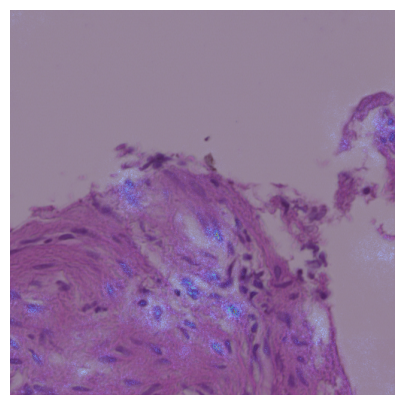

In [ ]:
import matplotlib.pyplot as plt

display_np = display_tile.permute(1, 2, 0).numpy()

plt.figure(figsize=(5, 5))
plt.imshow(display_np)
plt.imshow(sal_map, cmap="turbo", alpha=0.5)
plt.axis("off")
plt.margins(0)
plt.show()

### CAM (Class Activation Mapping)

Our classification head is `backbone → GlobalPool → Linear(512 → 1)`. CAM exploits
this directly: the 512 last-conv feature maps already are the features the linear
layer scores, so we just weight each feature map by its linear weight and sum:

$$\text{CAM} = \text{ReLU}\Big(\sum_k w_k \, A_k\Big)$$

The result lives at the feature-map resolution (`tile / 32` for VGG), so we
upsample it back to the tile.

> **A subtlety:** textbook CAM assumes *average* pooling, but our head uses
> *max* pooling — only the single peak location actually drives the logit. So
> CAM here highlights regions that *share the discriminative pattern*, not
> strictly what the max-pool selected. Grad-CAM (next) sidesteps this.

In [ ]:
import torch
from captum.attr import LayerActivation, LayerAttribution

activations = LayerActivation(model, model.backbone).attribute(
    input_tile
)  # (1, 512, H', W')
w = model.decode_head.proj.weight.detach()  # (1, 512)

cam = torch.relu(
    (w.view(1, -1, 1, 1) * activations).sum(dim=1, keepdim=True)
)  # (1, 1, H', W')
cam = LayerAttribution.interpolate(cam, (H, W), interpolate_mode="bilinear")
cam_map = normalize01(cam.squeeze().detach().cpu().numpy())

print(
    "CAM feature-map grid:",
    tuple(activations.shape[-2:]),
    "→ upsampled to",
    cam_map.shape,
)

CAM feature-map grid: (16, 16) → upsampled to (512, 512)


And let's view the output:

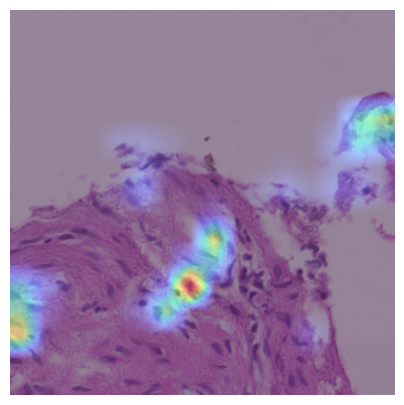

In [ ]:
import matplotlib.pyplot as plt

display_np = display_tile.permute(1, 2, 0).numpy()

plt.figure(figsize=(5, 5))
plt.imshow(display_np)
plt.imshow(cam_map, cmap="turbo", alpha=0.5)
plt.axis("off")
plt.margins(0)
plt.show()

### Grad-CAM

Grad-CAM generalizes CAM: instead of the fixed linear weights, it weights each
feature map by how much its activation *gradient* contributes to the target —
the channel-wise global average of `∂ logit / ∂ A_k`. That removes the
dependence on the head's exact form, so it works for any architecture. We target
the **last conv block** (the backbone output, the same feature maps CAM used),
making the two directly comparable.

In [ ]:
from captum.attr import LayerGradCam

gradcam = LayerGradCam(model, model.backbone)
gc = gradcam.attribute(input_tile, target=0, relu_attributions=True)  # (1, 1, H', W')
gc = LayerAttribution.interpolate(gc, (H, W), interpolate_mode="bilinear")
gc_map = normalize01(gc.squeeze().detach().cpu().numpy())

print("Grad-CAM map shape:", gc_map.shape)

Grad-CAM map shape: (512, 512)


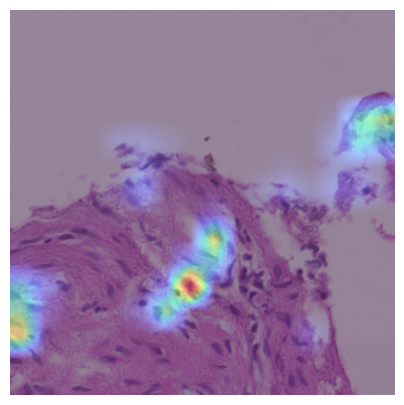

In [ ]:
import matplotlib.pyplot as plt

display_np = display_tile.permute(1, 2, 0).numpy()

plt.figure(figsize=(5, 5))
plt.imshow(display_np)
plt.imshow(gc_map, cmap="turbo", alpha=0.5)
plt.axis("off")
plt.margins(0)
plt.show()

### Compare the three

Side by side on the same tile. Look for: **saliency** is sharp but speckly;
**CAM** and **Grad-CAM** are smooth but coarse (they inherit the feature-map
resolution); and whether all three — plus your earlier **occlusion** map — agree
on the same tissue. Then the question that matters in pathology: do the
highlighted regions line up with diagnostically meaningful morphology (glandular
architecture, nuclei) rather than artifacts or edges?


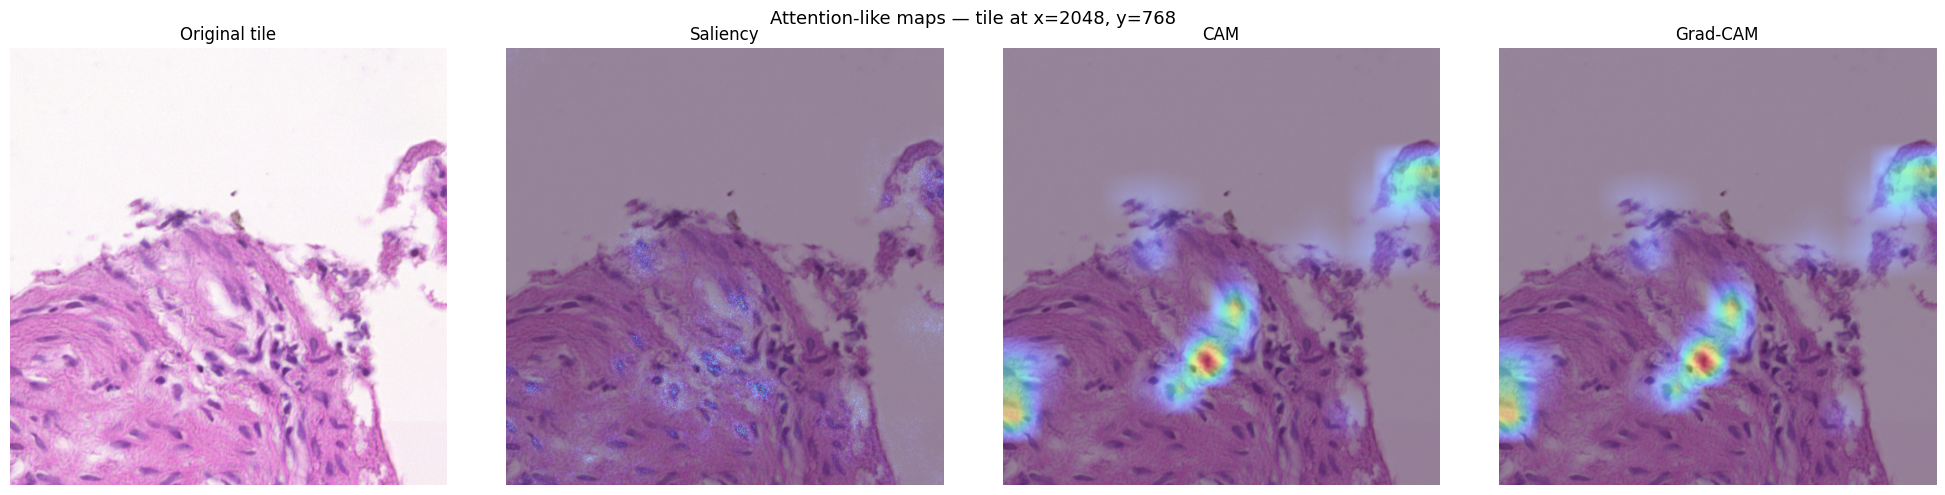

In [ ]:
import matplotlib.pyplot as plt

display_np = display_tile.permute(1, 2, 0).numpy()
maps = [("Saliency", sal_map), ("CAM", cam_map), ("Grad-CAM", gc_map)]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(display_np)
axes[0].set_title("Original tile")
axes[0].axis("off")

for ax, (name, m) in zip(axes[1:], maps):
    ax.imshow(display_np)
    ax.imshow(m, cmap="turbo", alpha=0.5)
    ax.set_title(name)
    ax.axis("off")

plt.suptitle(
    f"Attention-like maps — tile at x={metadata['x']}, y={metadata['y']}", fontsize=13
)
plt.tight_layout()
plt.show()

**What we see.** **Saliency** is diffuse and noisy — it fires on edges and
individual nuclei across the whole tile, which is hard to read as "where the
model looked." **CAM** and **Grad-CAM** are far more localized, concentrating on
a few focal regions of tissue rather than the background — and they look almost
identical. That match is expected, not a coincidence: with a
`GlobalPool → Linear` head, Grad-CAM's gradient-derived weights reduce to (a
multiple of) the linear weights CAM uses directly, so the two collapse to the
same map. Grad-CAM *generalizes* CAM; on a head this simple it gives CAM back.

The open question — and the one that matters clinically — is whether those
highlighted regions correspond to diagnostically meaningful morphology, or just
to high-contrast structures the network latches onto. We keep that skepticism for
the critical lens below.

<table cellpadding="16" cellspacing="0" border="0"><tr><td bgcolor="#E1F5EE">
<font size="6" color="#085041"><b>Try this — explore the gradient-based maps</b></font>
<br><br>
<font size="4" color="#0a3d31">
These maps also have knobs worth poking at.
<br><br>
&nbsp;&nbsp;•&nbsp; <b>Target layer.</b> Grad-CAM and CAM read the backbone's last conv block (<font size="4" face="Courier New, monospace" color="#7a2e0e"><b>model.backbone</b></font>). Try pointing Grad-CAM at an <i>earlier</i> block,</br> e.g. <font size="4" face="Courier New, monospace" color="#7a2e0e"><b>LayerGradCam(model, model.backbone[23])</b></font>, and notice how the map gets sharper but less semantic as you move shallower.
<br>&nbsp;&nbsp;•&nbsp; <b>The tile.</b> Change <font size="4" face="Courier New, monospace" color="#7a2e0e"><b>tile_dataset[0]</b></font> in the <i>Load a tile</i> cell to another index and re-run the three methods — do saliency, CAM and</br>Grad-CAM still agree?
<br>&nbsp;&nbsp;•&nbsp; <b>Colormap and opacity.</b> In the plotting cells, swap <font size="4" face="Courier New, monospace" color="#7a2e0e"><b>cmap="turbo"</b></font> for <font size="4" face="Courier New, monospace" color="#7a2e0e"><b>"jet"</b></font>, <font size="4" face="Courier New, monospace" color="#7a2e0e"><b>"viridis"</b></font>, or <font size="4" face="Courier New, monospace" color="#7a2e0e"><b>"inferno"</b></font>, and adjust <font size="4" face="Courier New, monospace" color="#7a2e0e"><b>alpha=0.5</b></font></br>to make the overlay lighter or stronger.
<br>&nbsp;&nbsp;•&nbsp; <b>ReLU.</b> Grad-CAM uses <font size="4" face="Courier New, monospace" color="#7a2e0e"><b>relu_attributions=True</b></font>, which keeps only evidence <i>for</i> the class. Set it to <font size="4" face="Courier New, monospace" color="#7a2e0e"><b>False</b></font> to also see regions that</br>push <i>against</i> the prediction.
<br><br>
Re-run from your change downward to see the effect.
</font>
</td></tr></table>

### From a tile to the whole slide (Grad-CAM)

Because Grad-CAM costs ~one backward pass, we can run it over **every** tile of
the slide live — the thing occlusion was too slow to do. We accumulate the
per-tile maps with the same `MaskBuilder` infrastructure, then normalize the
whole slide once at the end (so low-attention tissue stays dark instead of every
tile being stretched to full brightness).

In [ ]:
import numpy as np
from tqdm.notebook import tqdm
from ratiopath.masks.mask_builders import MaskBuilder, MaxAggregator

attention_builder = MaskBuilder(
    source_extents=(slide_metadata["extent_x"], slide_metadata["extent_y"]),
    source_tile_extent=(
        slide_metadata["tile_extent_x"],
        slide_metadata["tile_extent_y"],
    ),
    output_tile_extent=(
        slide_metadata["tile_extent_x"],
        slide_metadata["tile_extent_y"],
    ),
    stride=(slide_metadata["stride_x"], slide_metadata["stride_y"]),
    n_channels=1,
    storage="memmap",
    aggregation=MaxAggregator,
    dtype=np.float32,
)

model.eval()  # Grad-CAM needs gradients, so no torch.no_grad() here
for tile, metadata in tqdm(tile_dataset, desc="Grad-CAM", total=len(tile_dataset)):
    inp = tile.unsqueeze(0).to(device)
    attr = gradcam.attribute(inp, target=0, relu_attributions=True)
    attr = LayerAttribution.interpolate(
        attr, (inp.shape[-2], inp.shape[-1]), interpolate_mode="bilinear"
    )

    m = attr.squeeze().detach().cpu().numpy().astype(np.float32)  # (H, W), ≥ 0
    coords = np.array([[metadata["x"], metadata["y"]]])
    attention_builder.update_batch(m[None, None], coords)

Grad-CAM:   0%|          | 0/495 [00:00<?, ?it/s]

### Save the Grad-CAM slide mask

Grad-CAM is non-negative and unipolar, so there's no neutral midpoint to worry
about — low attention and the empty background both sit near `0`, which is what
we want them to do (they fade out). We normalize the whole slide to `[0, 255]`
and write it like the occlusion masks.

In [ ]:
import pyvips
from ratiopath.masks import write_big_tiff

attention_result = attention_builder.finalize()
att = attention_result[0].T
att = att / (att.max() + 1e-8)  # global [0, 1]
att_byte = (att * 255).astype(np.uint8)

write_big_tiff(
    pyvips.Image.new_from_array(att_byte).cast("uchar"),
    "ECDP2026/gradcam_mask.tiff",
    float(slide_metadata["mpp_x"]),
    float(slide_metadata["mpp_y"]),
)

### A critical lens

Pretty heatmaps invite over-trust. Three things to keep in mind:

- **They are correlational, not causal.** Saliency/CAM/Grad-CAM report what
  *correlates* with the output through the network's internals; occlusion, by
  actually removing tissue, is closer to a causal test. When they disagree,
  that's informative.
- **Sanity checks matter** (Adebayo et al., 2018): some saliency maps barely
  change when the model's weights are randomized — i.e. they can behave like
  edge detectors rather than explanations. Always ask whether a map actually
  depends on the trained model.
- **Resolution and faithfulness.** CAM/Grad-CAM are coarse (feature-map grid);
  saliency is fine but noisy. None is "the" explanation — they're complementary
  views, which is exactly why we showed perturbation- *and* gradient-based
  methods.

  > Hover over intereting areas to uncover the underlying slide features.

In [ ]:
display(server,
 {
    "params": { "activeBackgroundIndex": [0],
               "bypassCache": True, "ui": {"globalMenu": False}, "disablePluginsUi": True },
    "data": [ "ECDP2026/slide.tiff", "ECDP2026/gradcam_mask.tiff"],
    "background": [{"dataReference": 0, "goalIndex": 0}, {"dataReference": 0, "goalIndex": 1}],
    "visualizations": [
        {
            "name": "GradCam",
            "shaders": {
                "gradcam-ours": {
                    "name": "Gradcam",
                    "type": "colormap",
                    "fixed": False,
                    "dataReferences": [1],
                    "params": {
                        "use_gamma": 1,
                        "opacity": 0.8,
                        "connect": False,
                        "color": {
                            "type": "colormap",
                            "default": "Turbo",
                            "steps": 5,
                            "mode": "sequential",
                            "continuous": True
                        },
                        "threshold": {
                             "breaks": [0.2, 0.4, 0.8, 0.9],
                             "mask": [0,1,1,1,1]
                        }
                    }
                }
            }
        }
    ],
     "plugins": {
      "extra-tutorials": {
          "data": [{
              "title": "GradCam comparison: align and inspect",
              "attach": True,
              "runDelay": 600,
              "confirm": {
                  "title": "Compare your GradCam to the reference",
                  "message": (
                      "Two viewers side-by-side: the <b>precomputed reference</b> "
                      "and <b>your model's output</b>. We'll align them with a "
                      "couple of clicks so you can scrutinize differences."
                  ),
                  "acceptLabel": "Walk me through it",
                  "declineLabel": "Skip"
              },
              "content": [
                  {"next #osd-0":
                      "On the slide we can see the computed GradCam overlay."},
                  {"click #osd-0-right-menu-menu-b-opened-shaders":
                      "Click here to open the Layers tab as before."},
                  {"click #osd-0-scale-bar-magnification button[title='Enable sync']":
                      "Click <b>LINK</b> on the left viewer's scale-bar widget to start a sync session. "
                      "This puts the left viewer into anchor-picking mode."},
                  {"next #osd-0":
                      "Now click <b>three corresponding anatomical points</b> directly on the LEFT slide "
                      "— landmarks you can recognise on the right slide too. "
                      "Press <b>NEXT</b> when you've placed them."},
                  {"click #osd-1-scale-bar-magnification button[title='Enable sync']":
                      "Click <b>LINK</b> on the RIGHT viewer. Because both viewers reference the same "
                      "slide ID (<code>ECDP2026/slide.tiff</code>), your three anchors transfer automatically "
                      "and the right viewport snaps into alignment."},
                  {"next #viewer-container":
                      "Synced! Pan or zoom in one viewer and the other follows. "
                      "The Layers panel on each side stays editable — tweak the colormap, opacity, "
                      "threshold breaks/mask — and compare your GradCam against the reference in real time. "
                      "The UI is unblocked, so play freely."}
              ]
          }]
      }
  }
}, "100%", 600)


<IPython.core.display.Javascript object>

---
## Task: Activation Clustering

So far, the explanations answered questions like: **which part of this image influenced this prediction?** Activation clustering answers a different question: **what kinds of visual patterns does the model represent internally?**

This section is based on the paper **"Explaining Digital Pathology Models via Clustering Activations"** by Bajger et al. The paper proposes clustering CNN activation vectors from pathology tiles to reveal model-internal tissue patterns across whole-slide images.

A CNN does not only output one cancer score. Inside the network it builds many feature maps. Each location in a deep feature map is a compact description of a small tissue region. Activation clustering groups those descriptions into a small number of recurring model-internal patterns.

In this tutorial we will:

1. choose a deep CNN layer whose activations still have spatial structure
2. run the existing slide tiles through the model and save that layer's activations
3. stitch overlapping tile activations into one slide-level activation map
4. use NMF to group similar activation vectors into `n_clusters` classes
5. inspect several representative tissue patches for each class
6. export the class-intensity maps and view them as a whole-slide overlay in xOpat


### Step 1: choose the activation layer

We need a layer that satisfies two conditions:

- it is **deep enough** to describe meaningful tissue patterns rather than raw edges and colors
- it is **still spatial**, so each activation location can be mapped back to a region on the slide

For this VGG16 model, `model.backbone[29]` is the ReLU after the last convolutional layer. That is a good tutorial choice because it is deep, spatial, and non-negative.

The non-negative part matters because NMF cannot work with negative values.



In [ ]:
# Post-ReLU output of the deepest VGG16 convolutional block.
# For 512 x 512 tiles, this layer produces a 512-channel feature map.
target_layer = model.backbone[29]

### Step 2: Extract and Assemble Slide-Level Activations
To prepare our data for Non-Negative Matrix Factorization (NMF), we need to extract deep feature maps from individual tissue tiles and assemble them back into a single, seamless slide-level matrix. This process involves two core actions: collecting the raw activations and resolving overlapping tile boundaries.
1. **Extracting with Hooks**: We use a PyTorch forward hook (`ActivationCapture`) to intercept the output of our `target_layer` during the forward pass. Running this under `torch.inference_mode()` disables gradient tracking, drastically reducing memory consumption.
2. **Assembling and De-overlapping**: Because tissue tiles overlap, the same region may be observed multiple times. Furthermore, features near tile edges are less reliable. We handle this using `MaskBuilder`, which:
    * Crops a 2-pixel border from the feature maps (`edge_clipping=2`) to remove edge artifacts.
    * Places each tile's features back into its exact spatial coordinates on the Whole Slide Image (WSI).
    * Dynamically averages overlapping regions using a `MeanAggregator`.
    * Tracks covered regions via an `overlap_counter`.

Ultimately, we discard uncovered slide locations to produce a clean, finalized matrix structured for downstream clustering:
$$clean\_activations.T = (N, C)$$
Where N is the total number of covered slide-level feature locations and C is the number of feature channels. Each row represents a localized, deep-feature description of a small tissue region.

In [ ]:
from typing import Self
from torch import nn, Tensor
from torch.utils.hooks import RemovableHandle

class ActivationCapture:
    """Context manager that captures the output of one module."""

    def __init__(self, layer: nn.Module) -> None:
        self.layer = layer
        self.activation: Tensor | None = None
        self._handle: RemovableHandle | None = None

    def __enter__(self) -> Self:
        self._handle = self.layer.register_forward_hook(self._hook)
        return self

    def __exit__(self, exc_type, exc_value, traceback) -> None:
        if self._handle is not None:
            self._handle.remove()
            self._handle = None

    def _hook(self, module: nn.Module, inputs: tuple[Tensor, ...], output: Tensor) -> None:
        self.activation = output.detach().cpu()

In [ ]:
import numpy as np
from torch import nn, Tensor
from torch.utils.data import DataLoader
from tqdm import tqdm
from ratiopath.masks.mask_builders import MaskBuilder, MeanAggregator

# we need to get the output resolution
model.eval()
with ActivationCapture(target_layer) as capture, torch.inference_mode():
      model(torch.zeros(1, 3, 512, 512, device=device))
      _, c, h, w = capture.activation.shape

# collect the activations
activation_mask_builder = MaskBuilder(
    source_extents=(slide_metadata["extent_y"], slide_metadata["extent_x"]),
    source_tile_extent=(slide_metadata["tile_extent_y"], slide_metadata["tile_extent_x"]),
    output_tile_extent=(h, w),
    stride=(slide_metadata["stride_y"], slide_metadata["stride_x"]),
    n_channels=c,
    storage="memmap",
    aggregation=MeanAggregator,
    dtype=np.float32,
)
data_loader = DataLoader(
    tile_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

with ActivationCapture(target_layer) as capture, torch.inference_mode():
    for batch, coord in tqdm(data_loader):
        model(batch.to(device, non_blocking=True))

        coords = torch.stack([coord["y"], coord["x"]], dim=-1)
        activation_mask_builder.update_batch(capture.activation, coords, edge_clipping=2)


output = activation_mask_builder.finalize()

# Keep only slide-level feature locations that were covered by at least one tile.
mask = output["overlap_counter"][0] > 0
clean_activations = output["mask"][:, mask]

print("Slide activation mask:", output["mask"].shape)
print("Covered locations    :", int(mask.sum()))
print("NMF input matrix     :", clean_activations.T.shape)

100%|██████████| 16/16 [01:21<00:00,  5.10s/it]


Slide activation mask: (512, 576, 1760)
Covered locations    : 161568
NMF input matrix     : (161568, 512)


### Step 3: choose `K` and fit NMF

Now we ask NMF to find recurring activation patterns.

Think of the input matrix `V` as a table:

- each row is one slide location;
- each column is one CNN channel;
- each value says how active that channel was at that location.

NMF approximates this table as:

$$
V \approx W H
$$

`W` tells us **how strongly each class is present at each slide location**. `H` stores the learned class vectors. The class with the largest weight is the hard assignment for that location.

In [ ]:
from sklearn.decomposition import NMF

# Try 4, 6, or 8 and rerun the cells below.
n_clusters = 6

nmf = NMF(
    n_components=n_clusters,
    init="nndsvda",
    random_state=42,
    max_iter=500,
)

class_weights = nmf.fit_transform(clean_activations.T)
class_vectors = nmf.components_
flat_cluster_labels = class_weights.argmax(axis=1)

counts = np.bincount(flat_cluster_labels, minlength=n_clusters)
for cluster_id, count in enumerate(counts):
    percent = 100 * count / len(flat_cluster_labels)
    print(f"Class {cluster_id + 1}: {count:6d} activation locations ({percent:4.1f}%)")

print(f"NMF reconstruction error: {nmf.reconstruction_err_:.2f}")

Class 1:  16410 activation locations (10.2%)
Class 2:  21931 activation locations (13.6%)
Class 3:  20604 activation locations (12.8%)
Class 4:  22831 activation locations (14.1%)
Class 5:  44434 activation locations (27.5%)
Class 6:  35358 activation locations (21.9%)
NMF reconstruction error: 1019.17


### Step 4: inspect class representatives

Before opening the whole-slide overlay, inspect examples of what each class means.

For each NMF class, we select several slide locations where that class has a high weight. Then we crop patches from the original slide around those locations.

How to read this grid:

- each row is one NMF class;
- each column is one representative patch for that class;
- similar-looking patches in a row suggest that the class is capturing a coherent tissue pattern;
- mixed or noisy patches suggest that `n_clusters` may be too small, too large, or that this class is hard to interpret.

Do this inspection before trusting the overlay. The overlay is only useful once you have some idea what the colors/classes represent.


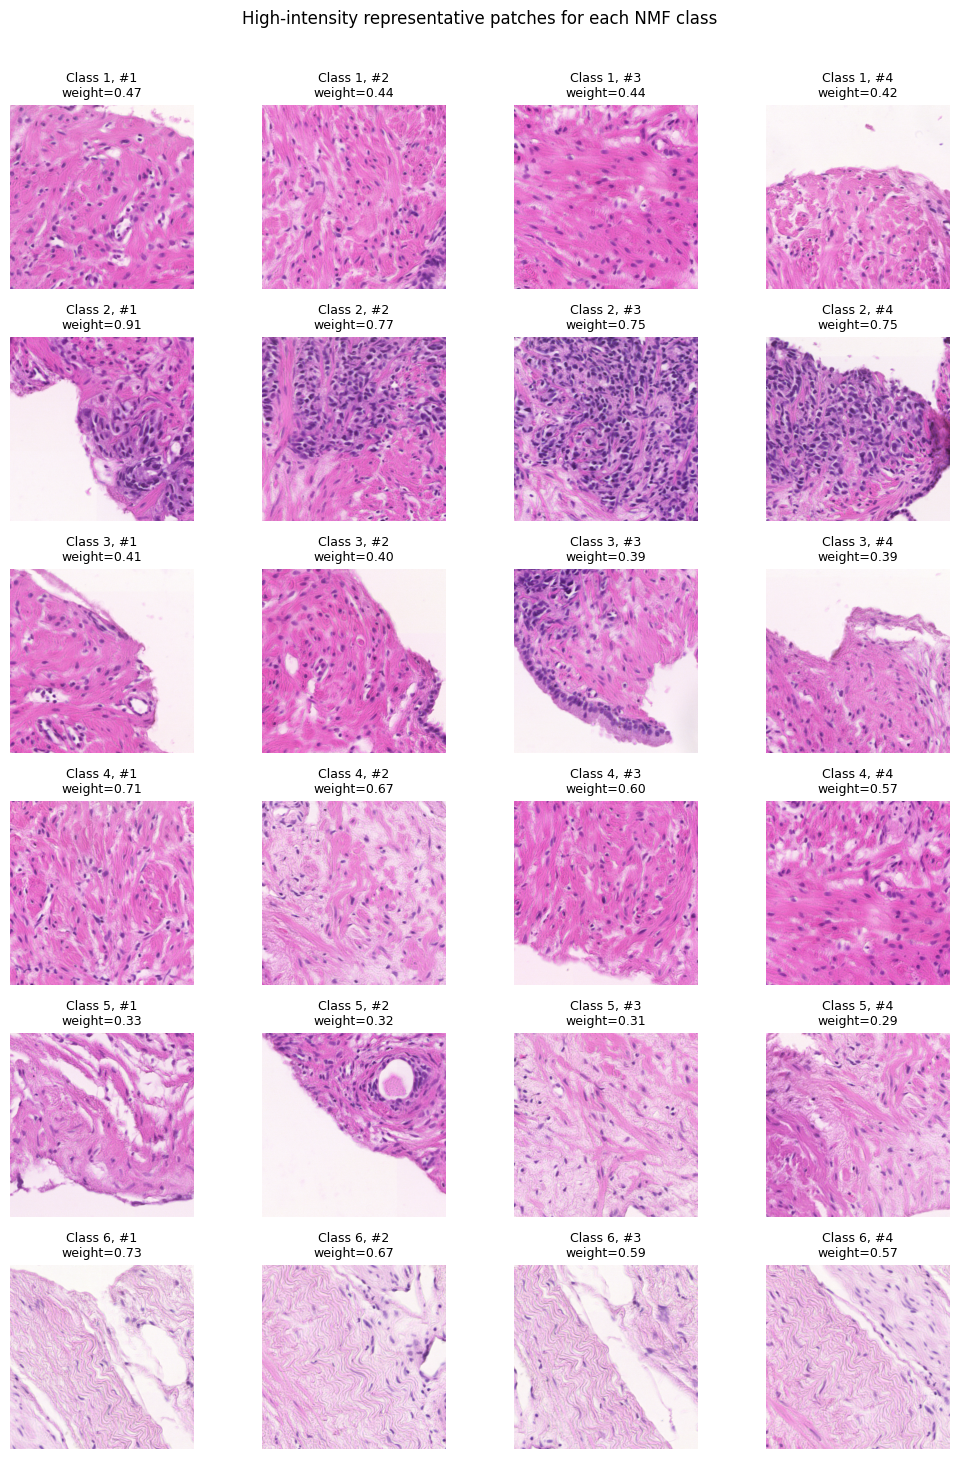

In [ ]:
import matplotlib.pyplot as plt
from ratiopath.openslide import OpenSlide


def feature_location_to_slide_xy(feature_y: int, feature_x: int, feature_shape: tuple[int, int]) -> tuple[int, int]:
    """Map a slide-level feature cell to an approximate source-pixel center."""
    feature_h, feature_w = feature_shape
    slide_y = int((feature_y + 0.5) * int(slide_metadata["extent_y"]) / feature_h)
    slide_x = int((feature_x + 0.5) * int(slide_metadata["extent_x"]) / feature_w)
    return slide_x, slide_y


def read_centered_patch(slide, center_x: int, center_y: int, size: int = 512):
    """Read a square patch centered at source-pixel coordinates."""
    x = max(0, center_x - size // 2)
    y = max(0, center_y - size // 2)
    return slide.read_tile(x, y, size, size, slide_metadata["level"])


def top_spaced_indices(scores: np.ndarray, locations: np.ndarray, n: int, min_distance: float) -> list[int]:
    """Pick high-scoring locations while avoiding near-duplicate neighboring patches."""
    selected: list[int] = []
    for candidate in np.argsort(scores)[::-1]:
        candidate_location = locations[candidate]
        if all(np.linalg.norm(candidate_location - locations[index]) >= min_distance for index in selected):
            selected.append(int(candidate))
        if len(selected) == n:
            break

    # If a class is spatially concentrated, fill the rest with the next-best locations.
    if len(selected) < n:
        for candidate in np.argsort(scores)[::-1]:
            if int(candidate) not in selected:
                selected.append(int(candidate))
            if len(selected) == n:
                break
    return selected


n_representatives_per_class = 4
representative_patch_size = 512
min_representative_distance = 8  # in slide-level feature cells

covered_feature_locations = np.column_stack(np.nonzero(mask))  # rows are (feature_y, feature_x)
representative_indices_by_class = [
    top_spaced_indices(
        scores=class_weights[:, class_id],
        locations=covered_feature_locations,
        n=n_representatives_per_class,
        min_distance=min_representative_distance,
    )
    for class_id in range(n_clusters)
]

fig, axes = plt.subplots(
    n_clusters,
    n_representatives_per_class,
    figsize=(2.6 * n_representatives_per_class, 2.4 * n_clusters),
    squeeze=False,
)

with OpenSlide(slide_metadata["path"]) as slide:
    for class_id in range(n_clusters):
        for representative_id, vector_index in enumerate(representative_indices_by_class[class_id]):
            ax = axes[class_id, representative_id]
            feature_y, feature_x = covered_feature_locations[vector_index]
            center_x, center_y = feature_location_to_slide_xy(feature_y, feature_x, mask.shape)
            patch = read_centered_patch(slide, center_x, center_y, size=representative_patch_size)

            ax.imshow(patch)
            title = (
                f"Class {class_id + 1}, #{representative_id + 1}\n"
                f"weight={class_weights[vector_index, class_id]:.2f}"
            )
            ax.set_title(title, fontsize=9)
            ax.axis("off")

plt.suptitle("High-intensity representative patches for each NMF class", y=1.01)
plt.tight_layout()
plt.show()

<table cellpadding="16" cellspacing="0" border="0"><tr><td bgcolor="#E1F5EE">
<font size="6" color="#085041"><b>Try this — reshape the clustering</b></font>
<br><br>
<font size="4" color="#0a3d31">
&nbsp;&nbsp;•&nbsp; <b>Number of clusters.</b> <font size="4" face="Courier New, monospace" color="#7a2e0e"><b>n_clusters = 6</b></font> matches the paper. Set it to <font size="4" face="Courier New, monospace" color="#7a2e0e"><b>4</b></font> (patterns merge into broader groups) or <font size="4" face="Courier New, monospace" color="#7a2e0e"><b>8</b></font> (they split into finer ones),</br>then re-run this cell and every cell below it.
<br>&nbsp;&nbsp;•&nbsp; <b>The activation layer.</b> We read <font size="4" face="Courier New, monospace" color="#7a2e0e"><b>model.backbone[29]</b></font>, the deepest post-ReLU conv output. Try a shallower layer such as <font size="4" face="Courier New, monospace" color="#7a2e0e"><b>model.backbone[26]</b></font></br>in the <i>choose the activation layer</i> cell — shallower layers capture simpler textures and edges rather than tissue-level patterns. (Keep it a post-ReLU</br>layer so the values stay non-negative for NMF.)
<br><br>
Remember to re-run all downstream cells after any change so the masks and overlay update.
</font>
</td></tr></table>

### Step 5: export probability-like class masks for xOpat

The representative patches show local examples. Now we export the whole-slide view.

Each NMF class becomes one channel in a TIFF file. To make the overlay easier to interpret, we convert raw NMF weights into **probability-like class proportions** at each slide location:

$$
p(class_k \mid location) = \frac{weight_k}{\sum_j weight_j}
$$

These are not calibrated probabilities from a supervised classifier. They are normalized NMF weights. The useful property is that, at each covered location, the class channels sum to approximately `1`. A bright class channel therefore means: "this class explains a large share of the local activation pattern."

In [ ]:
import numpy as np
import pyvips
from ratiopath.masks import write_big_tiff

# One output channel per NMF class, at slide-level feature-map resolution.
# Uncovered locations remain zero.
cluster_assignments = np.memmap(
    "cluster_assignments.dat",
    mode="w+",
    shape=(n_clusters, *mask.shape),
    dtype=np.float32,
)

# Convert raw NMF weights into per-location proportions.
# For each covered location, the class values sum to 1. This behaves more like
# a probability distribution than independently normalized heatmaps.
weight_sums = class_weights.sum(axis=1, keepdims=True)
class_proportions = np.divide(
    class_weights,
    weight_sums,
    out=np.zeros_like(class_weights, dtype=np.float32),
    where=weight_sums > 0,
)

cluster_assignments[:, mask] = class_proportions.T
cluster_assignments *= 255.0

# Resize from feature-map resolution back to slide/source resolution and write a pyramidal TIFF.
write_big_tiff(
    activation_mask_builder.resize_to_source(cluster_assignments.astype(np.uint8)),
    "ECDP2026/ac.tiff",
    float(slide_metadata["mpp_x"]),
    float(slide_metadata["mpp_y"]),
)

print("Saved probability-like activation clustering overlay to ECDP2026/ac.tiff")

Saved probability-like activation clustering overlay to ECDP2026/ac.tiff


The fact that we are saving all channels to a single file is not really imporant, we could also store N files and read them separatelly. Or any combination, really.

In [ ]:
# Open the generated multi-channel activation-clustering TIFF in xOpat.
# Use the layer controls to hide/show classes, change colors, and adjust opacity.
# Avoid pink/purple hues because they can be confused with H&E tissue colors.
# The palette is intentionally made from blues, greens, oranges, reds, browns, and grays.
base_cluster_colors = [
    "#1F77B4",  # blue
    "#2CA02C",  # green
    "#FF7F0E",  # orange
    "#D62728",  # red
    "#8C564B",  # brown
    "#17BECF",  # cyan
    "#BCBD22",  # olive
    "#7F7F7F",  # gray
    "#006D77",  # teal
    "#E76F51",  # coral
    "#264653",  # dark teal
    "#F4A261",  # sand orange
]
cluster_colors = [base_cluster_colors[cls % len(base_cluster_colors)] for cls in range(n_clusters)]

display(server,
 {
  "params": { "activeBackgroundIndex": 0, "bypassCache": True, "visualizationInspectorEnabled": True, "visualizationInspectorMode": "reveal-outside" },
  "data": [
      "ECDP2026/slide.tiff",
      {
        "dataID": "ECDP2026/ac.tiff",
        "options": {
            "format": "tiff",
            "channels": "all",
            "plugin": "tifffile"
        },
      }
  ],
  "background": [{ "dataReference": 0, "goalIndex": 0 }],
  "visualizations": [
    {
      "name": "Activation Clusters",
      "shaders": {
         **{f"class_{cls+1}": {
            "name": f"Class {cls+1} Heatmap",
            "type": "heatmap",
            "fixed": False,
            "dataReferences": [1],
            "params": {
                "opacity": 0.8,
                "use_channel_base0": cls,
                "threshold": 0,
                "color": {
                    "default": color,
                },
                "inverse": {
                    "interactive": False
                },
            }
          } for cls, color in enumerate(cluster_colors)
        }
      }
    },
     {
      "name": "Activation Clusters (Hatching)",
      "shaders": {
         **{f"class_{cls+1}_hatch": {
            "name": f"Class {cls+1} Pattern Map",
            "type": "patternmap",
            "fixed": False,
            "dataReferences": [1],
            "params": {
                "opacity": 0.9,
                "use_channel_base0": cls,
                "threshold": 0,
                "pattern_type": 2,
                "spacing": 7,
                "line_width": 2.5,
                "offset_x": 1.5*cls,
                "offset_y": 1.5*cls,
                "rotation": 17*cls,
                "color": {
                    "default": color,
                },
                "inverse": {
                    "interactive": False
                },
            }
          } for cls, color in enumerate(cluster_colors)
        }
      }
    }
  ],  "plugins": {
      "extra-tutorials": {
          "data": [{
              "title": "Activation Clusters: inspect & tweak",
              "attach": True,
              "runDelay": 600,
              "confirm": {
                  "title": "Inspect and reshape the cluster map",
                  "message": (
                      "Two quick things: how to peek under the overlay, "
                      "and how to reshape the colormap without touching the session config."
                  ),
                  "acceptLabel": "Show me",
                  "declineLabel": "Skip"
              },
              "content": [
                  {"next #osd-0":
                      "<b>Hover over the slide.</b> The visualization inspector "
                      "(<code>reveal-outside</code> mode) fades the cluster overlay away under your "
                      "cursor so you can see the H&amp;E underneath. Move the mouse away to bring it back."},
                  {"next #visual-menu-b-edit":
                      "The inspector is configurable from the <b>Edit</b> menu — toggle it off entirely, "
                      "or swap between <i>reveal-outside</i> (overlay disappears under cursor) and "
                      "<i>reveal-inside</i> (overlay shows only under cursor)."},
                  {"click #osd-0-right-menu-menu-b-opened-shaders":
                      "Open the <b>Layers</b> tab — that's where the you can play with individual classes. "
                      "You can also select a different style, a pattern heatmap from the top select."},
                  {"next #ac_classes-shader":
                      "<b>Activation Clusters shader.</b><br/>"
                      "• <b>Colormap</b> row: click any swatch to recolour that cluster.<br/>"
                      "• <b>Breaks</b> row: each dot is a threshold between two classes. "
                      "Click the bar <i>between</i> two breaks to mask out (hide) that class — "
                      "click again to bring it back. Drag a dot to shift the threshold.<br/>"
                      "• <b>Opacity</b> slider blends the whole overlay against the slide."},
                  {"next #osd-0":
                      "Want to experiment without touching the session? <b>Right-click anywhere on the "
                      "slide</b> and pick <b>Viewer → Open Visualization Playground</b>. "
                      "It clones the current visualization into a sandbox where you can change shader "
                      "type, palette, breaks, params — anything — and the underlying display() config "
                      "stays untouched."}
              ]
          }]
      }
  }
}, "100%", 600)

<IPython.core.display.Javascript object>

### What to check in the viewer

This demo follows the paper's core idea: use deepest post-ReLU CNN activations, factorize them with NMF, inspect class representatives, and visualize the class intensities across the whole slide.

When you open the overlay in xOpat, check three things:

1. **Do representatives match the overlay?** If a class representative looks like glands, edges, lumen, or dense nuclei, does that class appear in those regions on the slide?
2. **Does changing `n_clusters` change granularity as expected?** With `K = 4`, classes should be broader. With `K = 8`, classes should split into more specific patterns.
3. **Are any classes suspicious?** Classes that mostly highlight artifacts, blank regions, folds, or borders are still informative: they tell us what the model represents, even if it is not clinically meaningful.

Important limitation: in the paper, NMF is trained on many slides. In this tutorial, we train it on the prepared slide already loaded in the notebook. That makes the demo easier to run and understand, but the learned classes are less general.

---
## Task: Explaining a Prostate Vision Transformer with CRP

The CNN sections above explained a VGG16 classifier. Here we repeat the same idea for a **vision transformer** trained on 224 × 224 prostate tiles.

The model is a single-logit binary classifier: its output is the positive/tumor logit. The CRP question in this chapter is therefore:

> Which pixels support the model's positive/tumor output?

In the following example you can see CRP applied to an ImageNet ViT transformer. Ideally, we would like to achive something similar, but in reality, models train on digital pathology slides are much more chaotic.
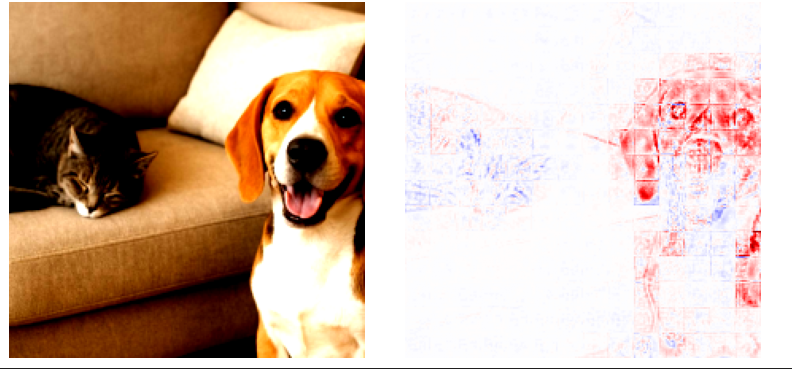

### Step 1: load the pretraied ViT model

In [ ]:
import torch
import timm

vit_model = timm.create_model("hf_hub:RationAI/vit-patch16-224-prostate", pretrained=True)
vit_model = vit_model.eval().to(device)
vit_model.requires_grad_(False)


vit_num_heads = int(vit_model.blocks[0].attn.num_heads)
vit_head_dim = int(vit_model.blocks[0].attn.head_dim)
vit_embed_dim = int(vit_model.embed_dim)
vit_num_blocks = len(vit_model.blocks)

print(f"Blocks: {vit_num_blocks} | heads: {vit_num_heads} | head dim: {vit_head_dim} | embed dim: {vit_embed_dim}")


### Step 2: 224 × 224 tile data

The VGG16 model above used 512 × 512 tiles. The ViT checkpoint was trained for 224 × 224 inputs, so we use the 224 tile coordinate parquet files and the same lazy WSI reader pattern.

The slide image itself is unchanged. Only the tile metadata changes. Keeping this as a second dataset avoids silently resizing 512 tiles and mixing two different sampling grids.


In [ ]:
import pandas as pd

vit_slide_metadata = pd.read_parquet("ECDP2026/slide_metadata_224.parquet").loc[0]
vit_slide_metadata["path"] = "ECDP2026/slide.tiff"
vit_tiles = pd.read_parquet("ECDP2026/tiles_224.parquet")

print(f"Total tiles  : {len(vit_tiles)}")

In [ ]:
from albumentations import Normalize

# The model was trained with the following normalization
vit_normalize = Normalize(
    mean=[0.5, 0.5, 0.5],
    std=[0.5, 0.5, 0.5],
)

vit_tile_dataset = TileDataset(
    vit_slide_metadata["path"],
    vit_slide_metadata["level"],
    vit_slide_metadata["tile_extent_x"],
    vit_slide_metadata["tile_extent_y"],
    vit_tiles,
    transforms=vit_normalize,
)

vit_tile_dataset_unnormalized = TileDataset(
    vit_slide_metadata["path"],
    vit_slide_metadata["level"],
    vit_slide_metadata["tile_extent_x"],
    vit_slide_metadata["tile_extent_y"],
    vit_tiles,
)

print(f"Model-ready ViT tiles: {len(vit_tile_dataset)}")
print(f"Display ViT tiles    : {len(vit_tile_dataset_unnormalized)}")


### Step 3: Build the CRP objects

The CRP machinery has two parts:

- `CondAttribution` runs relevance propagation for the selected output target.
- the AttnLRP composite defines how relevance flows through transformer operations such as linear layers, residual branches, softmax, and attention matmuls.

We compare three composites on two tiles below. For the whole-slide export we use `combined_lrp`, which gives the clearest positive-evidence signal for this checkpoint.

In [ ]:
from crp.attribution import CondAttribution
from crp.concepts import HeadConcept
from crp.helper import get_layer_names
from zennit_ext import (
    AttnLRPEpsilonComposite,
    AttnLRPGammaComposite,
    AttnLRPCombinedComposite,
    LRPInspectionLayer,
)

vit_lrp_composites = {
    "epsilon_lrp": AttnLRPEpsilonComposite(epsilon=1e-6),
    "gamma_lrp": AttnLRPGammaComposite(gamma=0.25, epsilon=1e-6),
    "combined_lrp": AttnLRPCombinedComposite(
        alpha=0.5,
        beta=0.5,
        linear_gamma=0.25,
        residual_lrp="ratio",
    ),
}

# Default used for the WSI export. The tile sanity check below shows why:
# epsilon is low-specificity here, while gamma/combined carry the tumor-logit sign signal.
vit_composite = vit_lrp_composites["combined_lrp"]
vit_attribution = CondAttribution(vit_model)

# Kept for the optional diagnostic below. Head-conditioned spatial maps are
# not used as the main result because they failed the mask-effect sanity check.
vit_head_concept = HeadConcept(num_heads=vit_num_heads)

with vit_composite.context(vit_model):
    vit_probe_layers = get_layer_names(vit_model, [LRPInspectionLayer])

print(f"LRP probe layers: {len(vit_probe_layers)}")
print("First probes:")
for name in vit_probe_layers[:6]:
    print("  ", name)

vit_layer_blocks = [0, vit_num_blocks // 2, vit_num_blocks - 1]
vit_probe_kinds = ["q", "k", "v"]
vit_head_layers = [
    f"blocks.{block}.attn.{kind}_lrp_probe"
    for block in vit_layer_blocks
    for kind in vit_probe_kinds
]


### CRP on a few positive and negative tiles

First we inspect individual tiles from both model-predicted classes. For a binary prostate classifier, class `0` is treated as **negative** and class `1` as **positive**; adjust `vit_class_names` if your checkpoint uses the opposite order.

For each selected tile we show:

1. the raw H&E tile,
2. the class-level AttnLRP heatmap for the predicted class,
3. heatmaps conditioned on the top relevant attention heads in the last block.

Positive relevance supports the selected class; negative relevance argues against it. Showing both negative and positive tiles helps students see whether the model uses different tissue evidence for absence versus presence of tumor.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Two fixed examples keep the tutorial deterministic:
#   tile 200: low positive probability in this slide
#   tile 59 : high positive probability in this slide
# They are not used for training or calibration; they are only visual examples.
vit_example_indices = [200, 59]


def normalize_heatmap_for_display(hm):
    """Return a signed heatmap and a symmetric display scale.

    Tile-level plots should preserve sign: positive values support the tumor
    logit, negative values suppress it. A symmetric scale makes red and blue
    comparable within the same tile.
    """
    hm = np.asarray(hm)
    vmax = float(np.nanmax(np.abs(hm))) if hm.size else 1.0
    return hm, (vmax if vmax > 0 else 1.0)


def tensor_to_image(tile_tensor):
    """Convert an unnormalized CHW tensor into a displayable HWC image."""
    return tile_tensor.detach().cpu().permute(1, 2, 0).numpy()


def positive_probability_from_base(x):
    """Compute p(tumor) for display without changing the attribution target."""
    raw_logits = vit_model(x)
    if raw_logits.ndim == 1:
        raw_logits = raw_logits[:, None]
    if raw_logits.shape[-1] == 1:
        return torch.sigmoid(raw_logits[:, 0])
    return torch.softmax(raw_logits, dim=-1)[:, 1]


def gradient_x_input_positive(tile):
    """Simple gradient baseline: input multiplied by d logit / d input.

    This is not CRP, but it is useful as a sanity baseline. It often looks
    noisy for ViTs, which makes the contrast with LRP-style methods easier to
    discuss.
    """
    x = tile.unsqueeze(0).to(device).detach().clone().requires_grad_(True)
    y = vit_model(x)
    if y.ndim == 1:
        y = y[:, None]
    y[:, 0].sum().backward()
    return (x.grad * x).sum(dim=1)[0].detach().cpu().numpy()


def lrp_positive(tile, composite, init_rel=None):
    """Run CRP/LRP for the positive logit on one tile."""
    x = tile.unsqueeze(0).to(device).detach().clone().requires_grad_(True)
    kwargs = {}
    if init_rel is not None:
        kwargs["init_rel"] = init_rel
    result = vit_attribution(
        x,
        [{"y": [0]}],
        composite,
        exclude_parallel=False,
        on_device="cpu",
        **kwargs,
    )
    return result.heatmap[0].detach().cpu().numpy()


vit_examples = []
for tile_index in vit_example_indices:
    tile, metadata = vit_tile_dataset[tile_index]
    display_tile, _ = vit_tile_dataset_unnormalized[tile_index]
    with torch.no_grad():
        p_pos = float(positive_probability_from_base(tile.unsqueeze(0).to(device))[0].detach().cpu())

    # Compute all attribution variants on exactly the same normalized model
    # input. This makes visual differences attributable to the explanation
    # method, not to preprocessing or tile selection.
    maps = {"grad × input": gradient_x_input_positive(tile)}
    for name, composite in vit_lrp_composites.items():
        # For the single positive logit, default output initialization is the
        # standard LRP choice: relevance starts at the logit value itself.
        maps[name] = lrp_positive(tile, composite, init_rel=None)

    vit_examples.append({
        "tile_index": tile_index,
        "metadata": metadata,
        "display": tensor_to_image(display_tile),
        "p_positive": p_pos,
        "maps": maps,
    })

for result in vit_examples:
    n_cols = 1 + len(result["maps"])
    fig, axes = plt.subplots(1, n_cols, figsize=(3.8 * n_cols, 3.8), squeeze=False)
    axes = axes[0]

    axes[0].imshow(result["display"])
    axes[0].set_title(
        f"tile {result['tile_index']}\n"
        f"p(positive)={result['p_positive']:.2f}"
    )
    axes[0].axis("off")

    for ax, (name, hm) in zip(axes[1:], result["maps"].items()):
        hm, vmax = normalize_heatmap_for_display(hm)
        ax.imshow(result["display"])
        ax.imshow(hm, cmap="seismic", vmin=-vmax, vmax=vmax, alpha=0.55)
        ax.set_title(name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


### Optional: head-conditioning diagnostic

CRP can, in principle, condition relevance on concepts such as attention heads. For this checkpoint, however, the head masks did not change the propagated input heatmap in our sanity check. That means per-head spatial heatmaps would be misleading, so the tutorial uses only plain positive-logit attribution.

The diagnostic below is kept as a useful lesson: concept explanations should be tested before they are trusted. If the reported differences are near zero, different head masks are producing effectively the same pixel map and should not be presented as distinct explanations.

In [ ]:
def head_mask_effect_diagnostic(tile_index, layer=None, heads=(0, 1, 2), composite=None):
    layer = layer or vit_head_layers[-1]
    composite = composite or vit_composite
    tile, _ = vit_tile_dataset[tile_index]
    maps = {}

    for head_id in heads:
        x = tile.unsqueeze(0).to(device).detach().clone().requires_grad_(True)
        result = vit_attribution(
            x,
            [{layer: [head_id], "y": [0]}],
            composite,
            mask_map=vit_head_concept.mask,
            exclude_parallel=False,
            on_device="cpu",
        )
        maps[head_id] = result.heatmap[0].detach().cpu().numpy()

    print(f"tile {tile_index} | layer {layer}")
    for i, h1 in enumerate(heads):
        for h2 in list(heads)[i + 1:]:
            diff = np.max(np.abs(maps[h1] - maps[h2]))
            scale = max(np.max(np.abs(maps[h1])), np.max(np.abs(maps[h2])), 1e-8)
            print(f"  max |H{h1} - H{h2}| / scale = {diff / scale:.6f}")
    return maps


# Try the last value probe first. Change `layer` to any printed probe name above.
_ = head_mask_effect_diagnostic(200, layer=vit_head_layers[-1], heads=(0, 1, 2), composite=vit_composite)


### Step 4: Whole-slide positive CRP

Now we run positive-logit gamma AttnLRP over all 224 × 224 tissue tiles and stitch a single **positive-evidence** heatmap back onto the WSI.

The exported TIFF keeps only relevance that supports the positive/tumor logit:

```python
hm_pos = np.maximum(hm, 0)
```

This differs from the tile plots above: tile plots are signed so we can inspect both supporting and opposing evidence, while the WSI overlay is unipolar because it answers a practical localization question: where does the model see positive/tumor evidence?

The final stitched mask is scaled to `0..255`, where `0` means no positive evidence and `255` means strongest positive evidence in the processed slide region. Increase `vit_wsi_batch_size` as GPU memory allows, and set `vit_wsi_limit = None` for the full slide.


In [ ]:
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader
from ratiopath.masks.mask_builders import MaskBuilder, MeanAggregator
import pyvips
from ratiopath.masks import write_big_tiff

vit_crp_builder = MaskBuilder(
    source_extents=(vit_slide_metadata["extent_y"], vit_slide_metadata["extent_x"]),
    source_tile_extent=(vit_slide_metadata["tile_extent_y"], vit_slide_metadata["tile_extent_x"]),
    output_tile_extent=(vit_slide_metadata["tile_extent_y"], vit_slide_metadata["tile_extent_x"]),
    stride=(vit_slide_metadata["stride_y"], vit_slide_metadata["stride_x"]),
    n_channels=1,
    aggregator=MeanAggregator,
    storage="memmap",
    dtype=np.float32,
)

vit_model.eval()
vit_wsi_limit = None  # set to None for the full slide
vit_wsi_batch_size = 32
vit_positive_clip_percentile = 99.0
vit_indices = list(range(len(vit_tile_dataset))) if vit_wsi_limit is None else list(range(min(vit_wsi_limit, len(vit_tile_dataset))))
vit_loader = DataLoader(
    torch.utils.data.Subset(vit_tile_dataset, vit_indices),
    batch_size=vit_wsi_batch_size,
    shuffle=False,
    num_workers=0,
)

for tiles_batch, metadata_batch in tqdm(vit_loader, desc="CRP over 224 tiles"):
    x = tiles_batch.to(device).detach().clone().requires_grad_(True)
    conditions = [{"y": [0]} for _ in range(x.shape[0])]

    result = vit_attribution(
        x,
        conditions,
        vit_composite,
        exclude_parallel=False,
        on_device="cpu",
        init_rel=1,
    )
    hm = result.heatmap.detach().cpu().numpy().astype(np.float32)
    hm_pos = np.maximum(hm, 0.0)

    positions = torch.stack([metadata_batch["y"], metadata_batch["x"]], dim=1)
    vit_crp_builder.update_batch(hm_pos[:, None], positions)

vit_crp_result = vit_crp_builder.finalize()
vit_crp_positive = vit_crp_result["mask"][0].astype(np.float32)

positive_values = vit_crp_positive[vit_crp_positive > 0]
if positive_values.size:
    positive_scale = np.percentile(positive_values, vit_positive_clip_percentile)
else:
    positive_scale = 1.0
positive_scale = float(positive_scale) if positive_scale > 0 else 1.0

vit_crp_norm = np.clip(vit_crp_positive / positive_scale, 0.0, 1.0)
vit_crp_byte = np.round(vit_crp_norm * 255.0).astype(np.uint8)

write_big_tiff(
    pyvips.Image.new_from_array(vit_crp_byte).cast("uchar"),
    "ECDP2026/vit_crp_positive_mask.tiff",
    float(vit_slide_metadata["mpp_x"]),
    float(vit_slide_metadata["mpp_y"]),
)

print(f"Positive encoding: 0 -> 0, +{positive_scale:.4g} -> 255")
if vit_crp_positive.size:
    print(f"Pixels with positive evidence: {((vit_crp_positive > 0).mean() * 100):.1f}%")


### View the positive ViT CRP mask in xOpat

The overlay is a positive-evidence heatmap over the WSI. Values near `0` mean little or no support for the positive/tumor logit; values near `255` are the strongest positive evidence in the processed slide region.


In [ ]:
display(server,
 {
    "params": { "activeBackgroundIndex": 0, "bypassCache": True },
    "data": [ "ECDP2026/slide.tiff", "ECDP2026/vit_crp_positive_mask.tiff"],
    "background": [{"dataReference": 0, "goalIndex": 0}],
    "visualizations": [
        {
            "name": "CRP mask",
            "shaders": {
                "gradcam": {
                    "name": "Gradcam",
                    "type": "colormap",
                    "fixed": False,
                    "dataReferences": [1],
                    "params": {
                        "use_gamma": 1,
                        "opacity": 0.8,
                        "connect": False,
                        "color": {
                            "type": "colormap",
                            "steps": 5,
                            "mode": "sequential",
                            "continuous": True
                        },
                        "threshold": {
                             "breaks": [0.01,0.25,0.5,0.75],
                             "mask": [0,1,1,1,1]
                        }
                    }
                }
            }
        },
    ],
}, "100%", 600)


### What to discuss

A few points are worth making explicit for students:

- This model has one learned output, so CRP explains evidence for the positive/tumor logit.
- Negative values in the tile maps are evidence against the positive logit, not a separate negative-class explanation.
- The WSI overlay intentionally shows only positive evidence, because that is the clinically useful question here: where does the model see tumor-supporting tissue?
- Concept-conditioned head heatmaps failed the mask-effect sanity check for this checkpoint, so they are not used as explanation results.



You made it to the end!

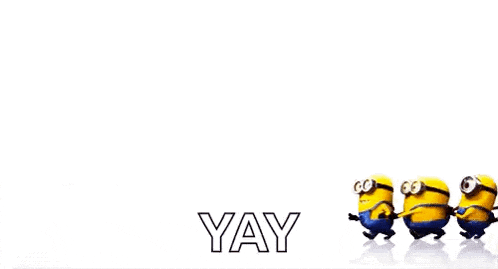


We will be grateful for your feedback here: https://muni.cz/go/ecdp26-feedback

The notebook URL is shared with you, you can create a copy. The xOpat viewer used in this notebook is freely available on [GitHub](https://github.com/RationAI/xopat).

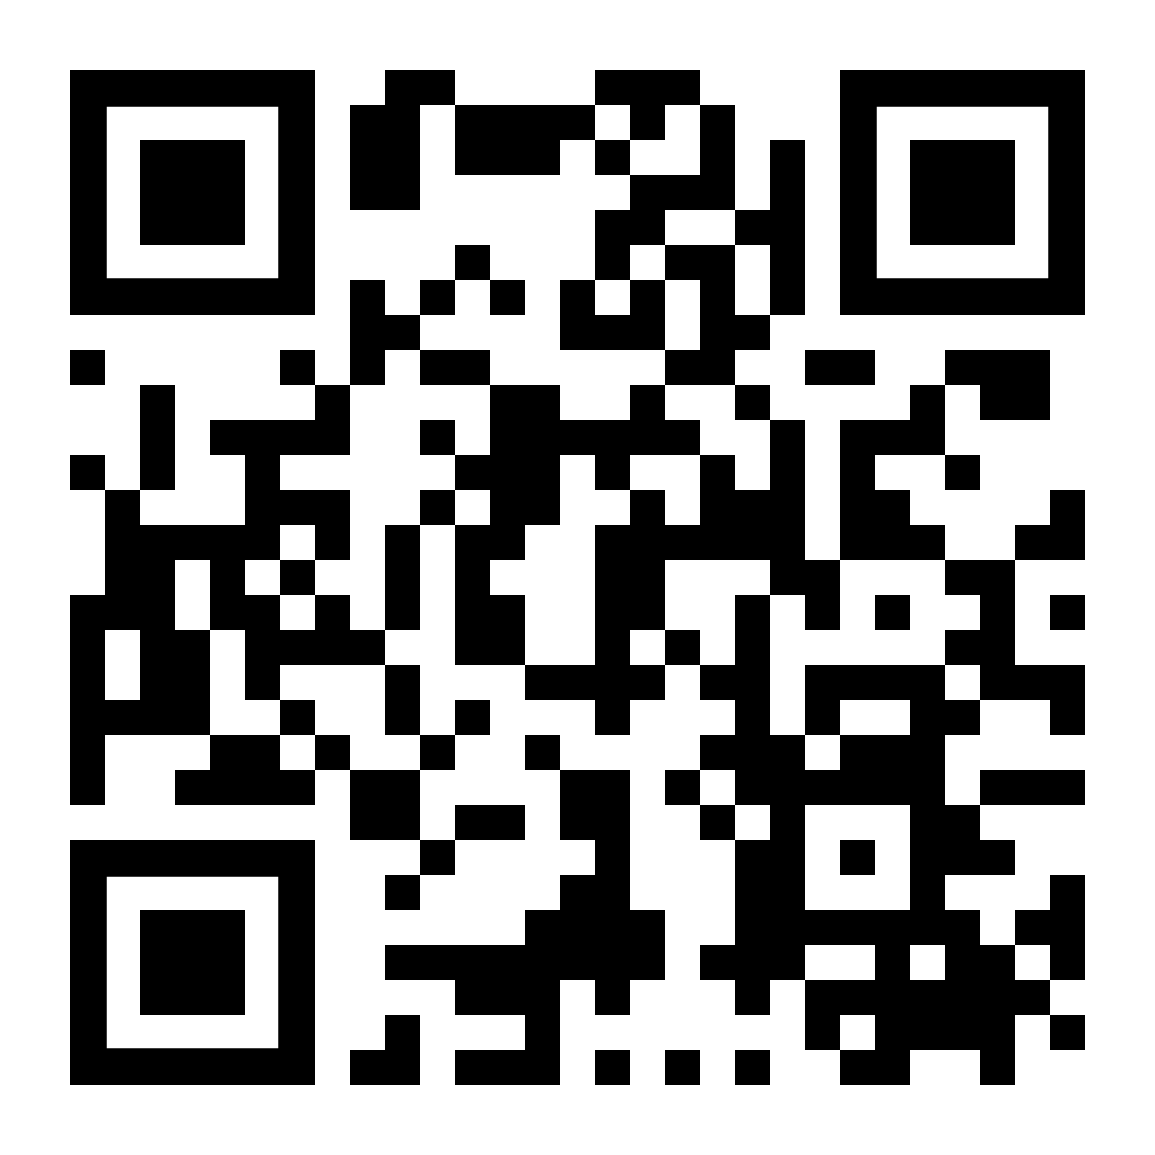